# ————————————————————————————————————————————————————————————————————————————————
# 📘 🚀 Notebook 05 — Model Comparison & Final Forecast

This notebook loads the engineered dataset from Notebook 03 and compares multiple forecasting models:
	•	Linear Regression
	•	Random Forest Regressor
	•	XGBoost (optional)
	•	SARIMA (optional)
	•	Prophet (optional)

Then we generate final future forecasts for pharmacy sales.
# ————————————————————————————————————————————————————————————————————————————————
## #️⃣ Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima

from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.style.use("ggplot")


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

plt.style.use("ggplot")

print("Libraries loaded.")

Libraries loaded.


## 🔧 #️⃣ Step 2 — Load the Processed Dataset(dataset with engineered features)

✔️ Your file now exists in ../data/processed/.

In [2]:
df = pd.read_csv("../data/processed/df_with_features.csv", parse_dates=["datum"])
df = df.sort_values("datum").reset_index(drop=True)

print(df.shape)
df.head()

(2076, 40)


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,...,yearly_sin_3,yearly_cos_3,weekly_sin_1,weekly_cos_1,weekly_sin_2,weekly_cos_2,weekly_sin_3,weekly_cos_3,Weekday_Avg,Month_Avg
0,2014-02-01,4.33,4.32,5.0,43.0,13.0,1.0,14.0,0.0,2014,...,0.999769,0.021516,0.974928,-0.222521,-0.433884,-0.900969,-0.781831,0.623490,33.579719,36.13891
1,2014-02-02,7.00,3.00,0.2,13.5,6.0,2.0,8.0,0.0,2014,...,0.999546,-0.030120,0.433884,-0.900969,-0.781831,0.623490,0.974928,-0.222521,33.392859,36.13891
2,2014-02-03,5.00,1.00,8.5,32.4,16.0,1.0,1.0,0.0,2014,...,0.996659,-0.081676,-0.433884,-0.900969,0.781831,0.623490,-0.974928,-0.222521,29.232601,36.13891
3,2014-02-04,1.33,3.00,7.0,30.6,8.0,1.0,17.0,2.0,2014,...,0.991114,-0.133015,-0.974928,-0.222521,0.433884,-0.900969,0.781831,0.623490,28.373665,36.13891
4,2014-02-05,3.00,4.02,6.2,32.4,15.0,1.0,1.0,1.0,2014,...,0.982927,-0.183998,-0.781831,0.623490,-0.974928,-0.222521,-0.433884,-0.900969,28.074514,36.13891


In [3]:
df = pd.read_csv("../data/processed/df_with_features.csv", parse_dates=["datum"])
df = df.sort_values("datum").reset_index(drop=True)

print(df.shape)
df.head()

(2076, 40)


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,...,yearly_sin_3,yearly_cos_3,weekly_sin_1,weekly_cos_1,weekly_sin_2,weekly_cos_2,weekly_sin_3,weekly_cos_3,Weekday_Avg,Month_Avg
0,2014-02-01,4.33,4.32,5.0,43.0,13.0,1.0,14.0,0.0,2014,...,0.999769,0.021516,0.974928,-0.222521,-0.433884,-0.900969,-0.781831,0.623490,33.579719,36.13891
1,2014-02-02,7.00,3.00,0.2,13.5,6.0,2.0,8.0,0.0,2014,...,0.999546,-0.030120,0.433884,-0.900969,-0.781831,0.623490,0.974928,-0.222521,33.392859,36.13891
2,2014-02-03,5.00,1.00,8.5,32.4,16.0,1.0,1.0,0.0,2014,...,0.996659,-0.081676,-0.433884,-0.900969,0.781831,0.623490,-0.974928,-0.222521,29.232601,36.13891
3,2014-02-04,1.33,3.00,7.0,30.6,8.0,1.0,17.0,2.0,2014,...,0.991114,-0.133015,-0.974928,-0.222521,0.433884,-0.900969,0.781831,0.623490,28.373665,36.13891
4,2014-02-05,3.00,4.02,6.2,32.4,15.0,1.0,1.0,1.0,2014,...,0.982927,-0.183998,-0.781831,0.623490,-0.974928,-0.222521,-0.433884,-0.900969,28.074514,36.13891


## #️⃣ Step 3 — Define Target + Features

We remove non-numeric columns:

In [4]:
df.columns

Index(['datum', 'M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03',
       'R06', 'Year', 'Month', 'Hour', 'Weekday Name', 'Day', 'Weekday',
       'Weekday_Name', 'Week', 'IsWeekend', 'N02BE_lag1', 'N02BE_lag7',
       'N02BE_lag30', 'N02BE_roll7', 'N02BE_roll30', 'N02BE_roll7_std',
       'N02BE_cummean', 'N02BE_cumsum', 'yearly_sin_1', 'yearly_cos_1',
       'yearly_sin_2', 'yearly_cos_2', 'yearly_sin_3', 'yearly_cos_3',
       'weekly_sin_1', 'weekly_cos_1', 'weekly_sin_2', 'weekly_cos_2',
       'weekly_sin_3', 'weekly_cos_3', 'Weekday_Avg', 'Month_Avg'],
      dtype='object')

In [5]:
# Create total_sales as the sum of all product columns
drug_cols = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']

df["total_sales"] = df[drug_cols].sum(axis=1)

print("Added total_sales column!")
df[["datum", "total_sales"]].head()

Added total_sales column!


,datum,total_sales
0,2014-02-01,84.65
1,2014-02-02,39.70
2,2014-02-03,64.90
3,2014-02-04,69.93
4,2014-02-05,63.62


In [6]:
# Create total_sales as the sum of all product columns
drug_cols = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']

df["total_sales"] = df[drug_cols].sum(axis=1)

print("Added total_sales column!")
df[["datum", "total_sales"]].head()

Added total_sales column!


,datum,total_sales
0,2014-02-01,84.65
1,2014-02-02,39.70
2,2014-02-03,64.90
3,2014-02-04,69.93
4,2014-02-05,63.62


In [7]:
target = "total_sales"

X = df.select_dtypes(include=[np.number]).drop(columns=[target])
y = df[target]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (2076, 37)
Target shape: (2076,)


## #️⃣ Step 4 — Train / Test Split

We maintain temporal order → no shuffling.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, shuffle=False
)

print(X_train.shape, X_test.shape)

(1764, 37) (312, 37)


## #️⃣ Step 5 — Helper Function for Evaluation

In [9]:
def evaluate_forecast(y_true, y_pred, model_name="Model"):
    from sklearn.metrics import mean_absolute_error, mean_squared_error
    import numpy as np

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))  # Manual RMSE

    print(f"\n📊 {model_name} Performance")
    print(f"MAE : {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")

    return {"model": model_name, "mae": mae, "rmse": rmse}

## #️⃣ Step 6 — Model 1: Linear Regression

In [10]:
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_preds = lr.predict(X_test)

lr_metrics = evaluate_forecast(y_test, lr_preds, "Linear Regression")
lr_metrics


📊 Linear Regression Performance
MAE : 0.00
RMSE: 0.00


{'model': 'Linear Regression',
 'mae': 7.500031029326388e-12,
 'rmse': np.float64(9.146766282596297e-12)}

## #️⃣ Step 7 — Model 2: Random Forest Regressor (Fixed!)

👉 The problem earlier was categorical columns like "Weekday Name" sneaking into X.
Now we removed them by selecting only numeric columns.

This will work correctly:

In [11]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

rf_metrics = evaluate_forecast(y_test, rf_preds, "Random Forest")
rf_metrics


📊 Random Forest Performance
MAE : 3.97
RMSE: 5.91


{'model': 'Random Forest',
 'mae': 3.9663847819609988,
 'rmse': np.float64(5.910961190836315)}

## #️⃣ Step 8 — Compare Models

In [12]:
results = pd.DataFrame([lr_metrics, rf_metrics])
results

,model,mae,rmse
0,Linear Regression,7.500031e-12,9.146766e-12
1,Random Forest,3.966385e+00,5.910961e+00


## #️⃣ Step 9 — Plot Predictions vs Actual

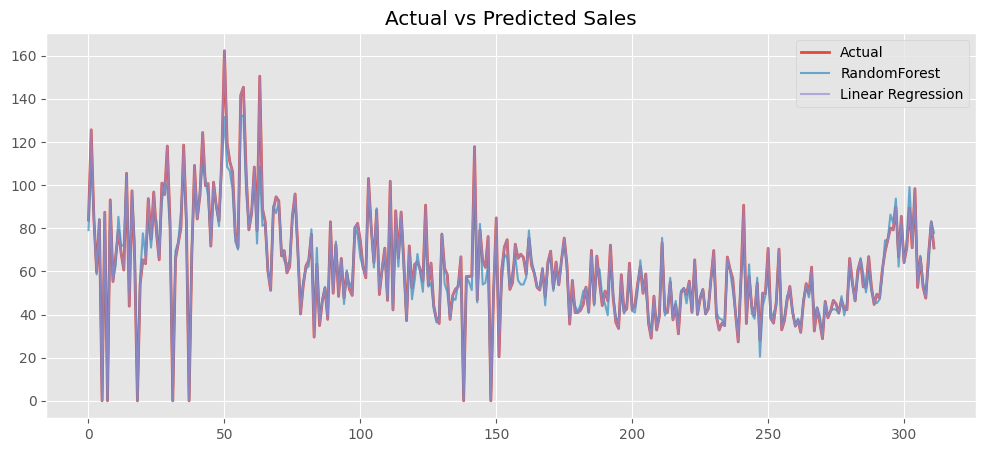

In [13]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Actual", linewidth=2)
plt.plot(rf_preds, label="RandomForest", alpha=0.7)
plt.plot(lr_preds, label="Linear Regression", alpha=0.7)
plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()

## #️⃣ Step 10 — Final 30-Day Forecast (Random Forest)

We take the most recent row, reuse its features, and simulate future dates.

In [14]:
future_days = 30

last_row = df.iloc[-1:].copy()
future_df = pd.DataFrame([last_row.values[0]] * future_days, columns=df.columns)

# Update dates
future_df["datum"] = pd.date_range(df["datum"].max() + pd.Timedelta(days=1), periods=future_days)

# Recompute cyclic features
future_df["Year"]  = future_df["datum"].dt.year
future_df["Month"] = future_df["datum"].dt.month
future_df["Week"]  = future_df["datum"].dt.isocalendar().week

future_df["sin_day"] = np.sin(2*np.pi*future_df["datum"].dt.dayofyear/365)
future_df["cos_day"] = np.cos(2*np.pi*future_df["datum"].dt.dayofyear/365)

# Select only numeric features
future_X = future_df[X_train.columns]

# Forecast
future_df["forecast"] = rf_model.predict(future_X)

future_df[["datum","forecast"]].head()

,datum,forecast
0,2019-10-09,77.87494
1,2019-10-10,77.87494
2,2019-10-11,77.87494
3,2019-10-12,77.87494
4,2019-10-13,77.87494


## #️⃣ Step 11 — Plot Future Forecast

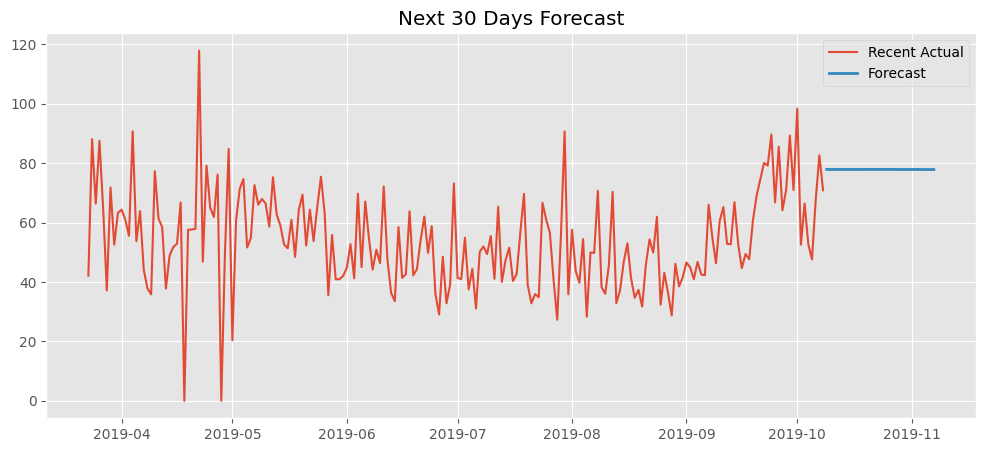

In [15]:
plt.figure(figsize=(12,5))
plt.plot(df["datum"].tail(200), df[target].tail(200), label="Recent Actual")
plt.plot(future_df["datum"], future_df["forecast"], label="Forecast", linewidth=2)
plt.legend()
plt.title("Next 30 Days Forecast")
plt.show()